# Atera reader — exploratory analysis (R / Seurat)

Loads a sample Atera (10x Genomics next-gen in-situ) output bundle with `LoadAtera()`,
runs a BPCells-backed sketch analysis (normalization, PCA, UMAP, clustering) that scales
to whole-transcriptome, millions-of-cell bundles, and visualizes results spatially.

This is the R/Seurat counterpart to `spatialdata-io`'s `atera_example.ipynb`, adapted to
two things that matter at this scale:

- **BPCells + sketching**, not a full in-memory/full-resolution pipeline: `FindClusters`
  and `RunPCA` on the full cell count are either infeasible or take tens of minutes (see
  the "Normalization, PCA, UMAP, clustering" section below for why). Seurat5's sketch
  workflow (`SketchData`/`ProjectData`) runs the expensive steps on a small,
  statistically-representative subset of cells, then projects the results back.
- **No whole-bundle segmentation polygons or morphology image.** `sp::SpatialPolygons()`
  (cell/nucleus segmentation boundaries) and `RBioFormats` (morphology TIFFs) don't scale
  to millions of cells either — the former can overflow R's protection stack well before
  that, and the latter is eagerly decoded in full. Both are loaded here only for specific,
  cropped regions of interest, via `LoadAteraSegmentations()` and a direct morphology
  region read.

## Setup: environment, R kernel, and sample data

Run these steps **once**, in a terminal (not in this notebook), before running the cells below.

### 1. Create the R/conda environment

```bash
micromamba create -n seurat_atera -c conda-forge "r-base>=4.0" r-irkernel -y
micromamba activate seurat_atera
```

(`conda create -n seurat_atera -c conda-forge "r-base>=4.0" r-irkernel -y && conda activate seurat_atera` works the same way if you use `conda` instead of `micromamba`.)

### 2. Clone this Seurat fork (with the Atera reader)

```bash
git clone --branch stephen/atera_update https://github.com/10XGenomics/seurat.git
cd seurat
```

### 3. Install R package dependencies

```r
# Start R
>R
install.packages(c("remotes", "BiocManager"))

# Adds the Bioconductor repos alongside CRAN, so install_deps() below can resolve
# Bioconductor-hosted dependencies (RBioFormats) as well as CRAN ones.
options(repos = BiocManager::repositories())

# Installs every dependency declared in DESCRIPTION, including ones only needed for
# the Atera reader specifically (BPCells, blosc, data.table, RBioFormats, sp, ...),
# which are listed there as optional ("Suggests") from the base package's point of
# view but are required for this notebook. BPCells isn't on CRAN/Bioconductor --
# DESCRIPTION's `Additional_repositories` field (bnprks.r-universe.dev) is what lets
# install_deps() find it.
remotes::install_deps(".", dependencies = TRUE)
```

### 4. Register the Jupyter kernel

```r
IRkernel::installspec(name = "seurat_atera", displayname = "R (seurat_atera)")
```

In Jupyter/VS Code, select the **"R (seurat_atera)"** kernel for this notebook.

### 5. Download the tiny sample dataset (optional, to smoke-test your setup)

This notebook is built around a whole-transcriptome/large bundle (see the intro above) --
that's the scale its BPCells/sketching approach is actually for -- but the same reader
works on 10x Genomics' small public sample too, which is a much quicker way to confirm
your environment and code changes are working before pointing at a real, large bundle.
It lives on the 10x Genomics support site:
https://cf.10xgenomics.com/samples/atera/1.0.0/tiny_atera_dataset/tiny_atera_dataset_outs.zip
Download it with `curl`:

```bash
mkdir -p data/tiny_atera_dataset
cd data/tiny_atera_dataset
curl -O https://cf.10xgenomics.com/samples/atera/1.0.0/tiny_atera_dataset/tiny_atera_dataset_outs.zip
unzip tiny_atera_dataset_outs.zip
tar -xzvf morphology_2d.tar.gz
tar -xzvf morphology_3d.tar.gz
```

This creates a local folder containing the output bundle.

### 6. Point the notebook at your data

In the "Load data" cell below, set `BUNDLE_PATH` to whichever bundle you want to run
against. For a quick smoke test against the tiny sample:

```r
BUNDLE_PATH <- "data/tiny_atera_dataset"
```

For the real workload this notebook is built for -- a whole-transcriptome/large bundle,
where the BPCells cache and sketch-based workflow actually matter:

```r
BUNDLE_PATH <- "/path/to/your/output_bundle"
```

(Check with `ls <bundle_path>` -- it should contain files like `cell_feature_matrix.zarr.zip`,
`csc_cell_feature_matrix.zarr.zip`, `cells.zarr.zip`, `transcripts.zarr.zip`, and the
`morphology_2d`/`morphology_3d` folders.)

In [ ]:
options(vsc.dev.args = list(width = 1200, height = 1200))

suppressPackageStartupMessages({
  library(devtools)
  library(SeuratObject)
})
devtools::load_all("/Users/stephen.williams/git/seurat", quiet = TRUE)

# Match to your machine's core count -- see the "Normalization, PCA, UMAP,
# clustering" section below for which steps this actually speeds up.
setThreads(8)

## Load data

In [ ]:
BUNDLE_PATH <- "/Users/stephen.williams/git/spatialdata_data/big_sample"
CACHE_DIR <- "/Users/stephen.williams/git/spatialdata_data/atera_bpcells_cache"

atera.obj <- LoadAtera(
  data.dir = BUNDLE_PATH,
  fov = "fov",
  assay = "Atera",
  cell.centroids = TRUE,
  molecule.coordinates = TRUE,
  bpcells.dir = CACHE_DIR,
  segmentations = NULL,     # loaded on demand for crops only, see below
  morphology.image = FALSE  # loaded on demand for crops only, see below
)
atera.obj

# Check the data structures

Unlike the python/AnnData notebook, there's no separate streaming pass needed to
populate QC columns: `nCount_Atera`/`nFeature_Atera` (transcript counts / genes detected
per cell) are computed automatically when the assay is created and are already present
in `meta.data` (`obs`'s equivalent here).

In [3]:
Assays(atera.obj)

[1] "Atera"           "BlankCodeword"   "ControlCodeword" "ControlProbe"   
[5] "GenomicControl"

In [4]:
# Feature names, equivalent to sdata.tables["table"].var
head(rownames(atera.obj[["Atera"]]))

[1] "A1BG"    "A1CF"    "A2M"     "A2ML1"   "A3GALT2" "A4GALT"

In [5]:
# Cell metadata, equivalent to sdata.tables["table"].obs
head(atera.obj[[]])

,orig.ident,nCount_Atera,nFeature_Atera,nCount_BlankCodeword,nFeature_BlankCodeword,nCount_ControlCodeword,nFeature_ControlCodeword,nCount_ControlProbe,nFeature_ControlProbe,nCount_GenomicControl,nFeature_GenomicControl
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4294968807,SeuratProject,711,547,0,0,0,0,0,0,0,0
4294969844,SeuratProject,3359,1934,0,0,0,0,0,0,0,0
4294970188,SeuratProject,3315,1981,0,0,1,1,0,0,2,2
4294971756,SeuratProject,1281,821,0,0,0,0,0,0,0,0
4294971779,SeuratProject,4707,2713,0,0,0,0,0,0,0,0
4294975465,SeuratProject,3372,2256,0,0,1,1,0,0,0,0


# Plotting some QC values

(No DAPI overview here — per the scoping above, the morphology image is only read for
the cropped region further down, not for a whole-bundle overview.)

In [ ]:
ImageFeaturePlot(atera.obj, fov = "fov", features = "nCount_Atera", size = 0.3) +
  ggplot2::ggtitle("Transcript counts per cell")


In [ ]:
ImageFeaturePlot(atera.obj, fov = "fov", features = "nFeature_Atera", size = 0.3) +
  ggplot2::ggtitle("Genes detected per cell")

## Plot transcripts spatial distribution for a single gene

Transcript coordinates are lazy (see `LoadAteraMolecules()`): only the gene(s) requested
here get fetched, not the whole transcript table. Adjust `gene_name` to one actually
present in your panel — check `rownames(atera.obj[["Atera"]])` if unsure.

In [ ]:
gene_name <- "ACE2"

atera.obj <- LoadAteraMolecules(atera.obj, genes = gene_name)

ImageDimPlot(
  atera.obj,
  fov = "fov",
  boundaries = NULL,  # centroids only -- no segmentation polygons loaded
  size = 0.1,
  cols = "grey80",
  molecules = gene_name,
  mols.size = 0.3,
  mols.cols = "orange",
  axes = TRUE
) + ggplot2::ggtitle(paste(gene_name, "transcripts"))

## Plot transcripts for multiple genes

Set `genes` to two or more panel genes you want to compare spatially.

In [ ]:
genes <- c("ACE2", "EPCAM")  # adjust to genes present in your panel

atera.obj <- LoadAteraMolecules(atera.obj, genes = genes)

ImageDimPlot(
  atera.obj,
  fov = "fov",
  boundaries = NULL,
  size = 0.1,
  cols = "grey80",
  molecules = genes,
  mols.size = 0.3,
  mols.cols = c("orange", "cyan"),
  axes = TRUE
) + ggplot2::ggtitle("Multi-gene transcripts")

## Plot codewords

Atera panels include "codeword" pseudo-features (negative controls, unassigned/
deprecated codewords, etc.) alongside real genes -- these show up in `rownames()`
with names like `UnassignedCodeword_<id>`/`DeprecatedCodeword_<id>` and can be fetched
the same way as any other gene via `LoadAteraMolecules()`. List a few to pick one that
actually exists in your panel:

In [ ]:
gene_name <- "ACE2"
atera.obj <- LoadAteraCodewords(atera.obj, data.dir = BUNDLE_PATH, genes = gene_name)

codeword.labels <- sort(unique(grep(
  paste0("^", gene_name, "_codeword_"),
  Misc(atera.obj, "atera.molecules")$cache$gene,
  value = TRUE
)))
cat(length(codeword.labels), "codewords for", gene_name, "\n")

palette <- c("orange", "cyan", "magenta", "yellow", "green", "red")  # extend if a gene has more codewords than this

ImageDimPlot(
  atera.obj,
  fov = "fov",
  boundaries = NULL,
  size = 0.1,
  cols = "grey80",
  molecules = codeword.labels,
  mols.size = 0.3,
  mols.cols = palette[seq_along(codeword.labels)],
  axes = TRUE
) + ggplot2::ggtitle(paste(gene_name, "transcripts by codeword"))

In [ ]:
plots <- lapply(codeword.labels, function(cw) {
  ImageDimPlot(
    atera.obj,
    fov = "fov",
    boundaries = NULL,
    size = 0.1,
    cols = "grey80",
    molecules = cw,
    mols.size = 0.3,
    mols.cols = "orange",
    axes = TRUE
  ) + ggplot2::ggtitle(cw)
})
combined <- patchwork::wrap_plots(plots, ncol = length(plots))
combined

### Crop to a specific region

This is the one place in this notebook that loads segmentation polygons and the
morphology image — both scoped to a small region, which is what keeps them fast (see
the intro). Adjust `x`/`y` to a region of interest in your bundle's tissue coordinates.

In [ ]:
atera.obj[["fov.crop"]] <- Crop(
  atera.obj[["fov"]],
  x = c(3500, 4000),
  y = c(2000, 3000),
  coords = "tissue"
)

# Cell segmentation polygons, built only for the ~hundreds-to-low-thousands of cells
# in this crop (see LoadAteraSegmentations()'s docs for why this doesn't scale to the
# whole bundle: sp::SpatialPolygons() overflows R's protection stack well before that).
atera.obj <- LoadAteraSegmentations(
  atera.obj,
  data.dir = BUNDLE_PATH,
  fov = "fov.crop",
  segmentations = "cell"
)

ImageDimPlot(
  atera.obj,
  fov = "fov.crop",
  boundaries = "segmentations",
  size = 0.3,
  cols = "grey80",
  axes = TRUE,
  molecules = "ACE2",
  mols.size = 0.3,
  mols.cols = "orange",
  coord.fixed = FALSE
)


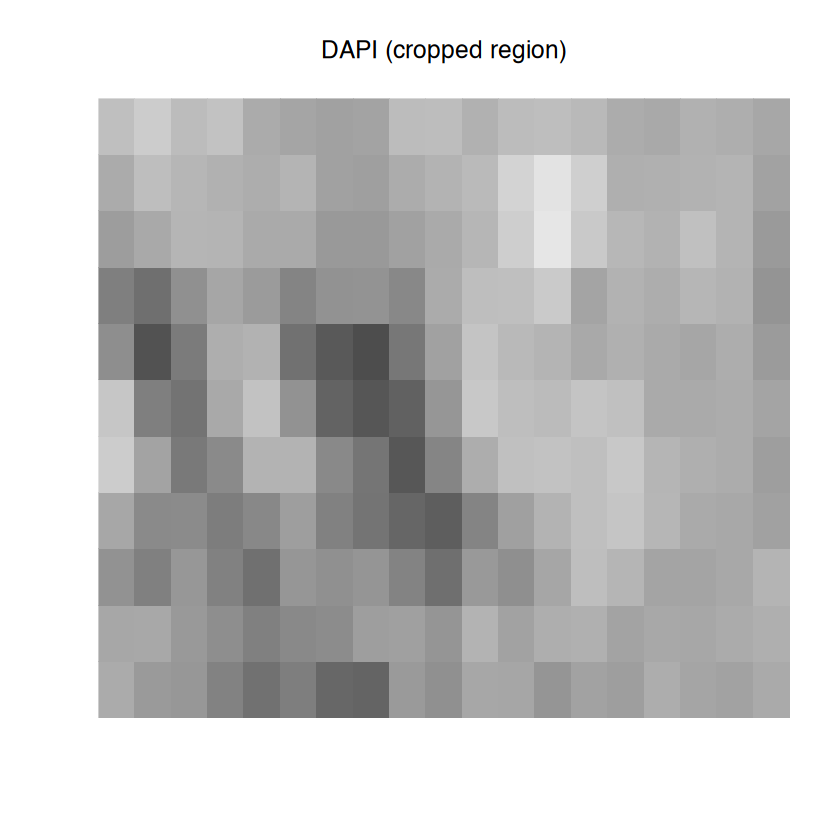

In [13]:
# DAPI morphology image, read directly for just this crop's region (micron
# coordinates) rather than via LoadAtera(morphology.image = TRUE), which would decode
# a whole-bundle plane eagerly on every call.
dapi.crop <- Seurat:::.AteraReadMorphologyImage(
  data.dir = BUNDLE_PATH,
  channel = "dapi",
  region = list(x = c(3500, 4000), y = c(2000, 3000))
)
image(
  t(dapi.crop$image)[, rev(seq_len(nrow(dapi.crop$image)))],
  col = grey.colors(256),
  axes = FALSE,
  main = "DAPI (cropped region)"
)

In [ ]:
ImageDimPlot(
  atera.obj,
  fov = "fov.crop",
  boundaries = "segmentations",
  size = 0.3,
  cols = "grey80",
  axes = TRUE,
  molecules = gene_name,
  mols.size = 0.3,
  mols.cols = "orange",
  coord.fixed = FALSE
) + 
ggplot2::ggtitle(paste("Cropped region:", gene_name, "+ cell boundaries"))

## Normalization, PCA, UMAP, clustering (BPCells + sketching)

At whole-transcriptome, millions-of-cell scale, the "standard" pipeline run directly on
every cell doesn't hold up:

- `FindClusters()`'s Louvain/SLM step is dominated by local-moving convergence, which can
  take tens of minutes to hours at this scale.
- `RunPCA()` on a BPCells-backed matrix goes through `BPCells::svds()`, which scales with
  cell count regardless of how it's invoked.

Seurat5's sketch workflow instead: subsamples a small, statistically-representative
"sketch" of cells via leverage-score weighting (`SketchData`), runs the expensive
normalize/PCA/cluster/UMAP steps on just the sketch, then projects the results (PCA
embedding, UMAP, cluster labels) back onto the full dataset (`ProjectData`).
`LeverageScore` (called internally by `SketchData`) has a dedicated `IterableMatrix`
code path, so this works directly on `atera.obj` -- no extra adaptation needed.

In [ ]:
atera.obj <- NormalizeData(atera.obj)
atera.obj <- FindVariableFeatures(atera.obj)
atera.obj <- SketchData(
  object = atera.obj,
  assay = "Atera",
  ncells = 100000L,
  sketched.assay = "sketch"
)
# SketchData() sets DefaultAssay to "sketch" -- the steps below all run on just the
# sketched cells, not the full dataset.

In [ ]:
atera.obj <- NormalizeData(atera.obj)
atera.obj <- FindVariableFeatures(atera.obj)
atera.obj <- ScaleData(atera.obj, features = VariableFeatures(atera.obj))

In [ ]:
atera.obj <- RunPCA(atera.obj, features = VariableFeatures(atera.obj), npcs = 30)

In [ ]:
atera.obj <- FindNeighbors(atera.obj, dims = 1:30)
# algorithm = 3 (SLM) scales better than the default Louvain at this cell count;
# n.start matches setThreads() above so the n.start random restarts split evenly
# across threads (see FindNeighbors/FindClusters threading notes).
atera.obj <- FindClusters(atera.obj, resolution = 1.0, algorithm = 3, n.start = 8)
# return.model = TRUE is required for ProjectData() to be able to project the full
# dataset into this sketch's UMAP space below.
atera.obj <- RunUMAP(atera.obj, dims = 1:30, return.model = TRUE)
DimPlot(atera.obj, group.by = "seurat_clusters", label = TRUE) + NoLegend()

## Project sketch results back onto the full dataset

`full.reduction`/`umap.model` together determine the output reduction names:
`"pca.full"` (PCA embedding for every cell) and `"full.umap"` (UMAP embedding for every
cell, derived from `umap.model`'s name) — the latter only gets created if `RunUMAP()`
above was called with `return.model = TRUE`.

In [ ]:
atera.obj <- ProjectData(
  object = atera.obj,
  assay = "Atera",
  sketched.assay = "sketch",
  sketched.reduction = "pca",
  full.reduction = "pca.full",
  dims = 1:30,
  umap.model = "umap",
  refdata = list(cluster_full = "seurat_clusters")
)
DefaultAssay(atera.obj) <- "Atera"

## Plot the clusters

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



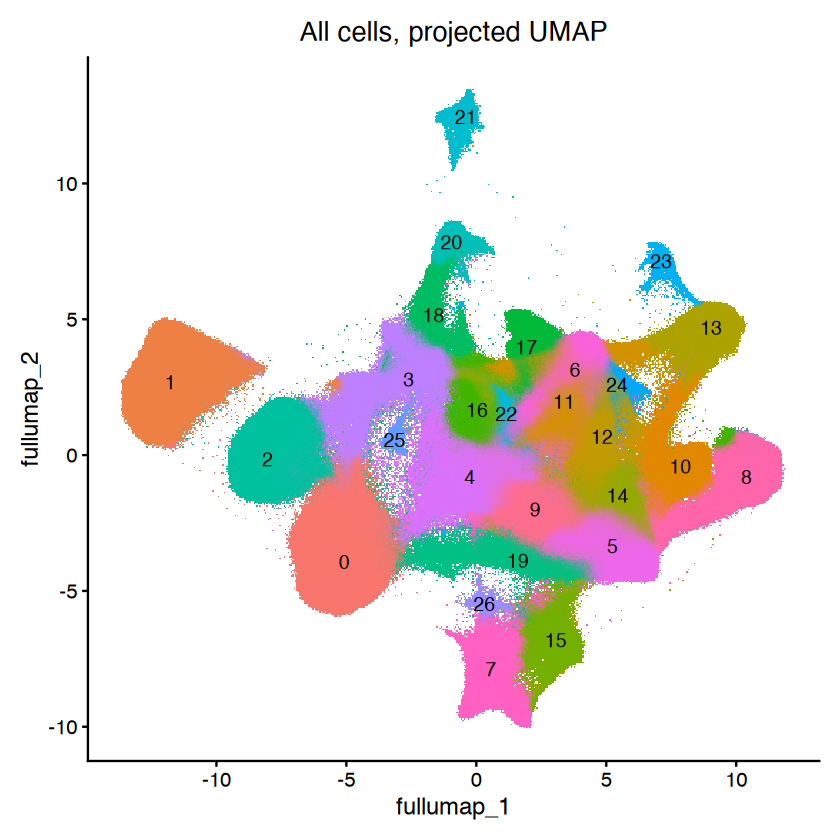

In [20]:
DimPlot(atera.obj, reduction = "full.umap", group.by = "cluster_full", label = TRUE) +
  NoLegend() + ggplot2::ggtitle("All cells, projected UMAP")

In [ ]:
# Whole-bundle overview: centroids only, no segmentation polygons (see intro).
ImageDimPlot(atera.obj, fov = "fov", group.by = "cluster_full", size = 0.1) +
  ggplot2::ggtitle("Clusters, all cells (centroids only)")

In [ ]:
# Cropped-region view reusing the segmentation polygons loaded earlier: real cell
# boundaries, not just points, since this FOV is small enough for it to be fast.
ImageDimPlot(
  atera.obj,
  fov = "fov.crop",
  group.by = "cluster_full",
  boundaries = "segmentations",
  size = 0.3
) + ggplot2::ggtitle("Clusters, cropped region (with cell boundaries)")
